In [1]:
!pip install shap xgboost scikit-learn imbalanced-learn matplotlib

print("✅ Done!")

✅ Done!


In [2]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")

✅ Libraries imported!


In [3]:
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes',
    'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
    'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
    'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

train_df = pd.read_csv(
    'https://raw.githubusercontent.com/logesh-GIT001/Smart-SOC/main/data/raw/KDDTrain%2B.txt',
    names=columns
)
test_df = pd.read_csv(
    'https://raw.githubusercontent.com/logesh-GIT001/Smart-SOC/main/data/raw/KDDTest%2B.txt',
    names=columns
)

# Drop useless columns
train_df.drop(columns=['num_outbound_cmds', 'difficulty'], inplace=True)
test_df.drop(columns=['num_outbound_cmds', 'difficulty'], inplace=True)

# Encode categorical columns
le = LabelEncoder()
cat_cols = ['protocol_type', 'service', 'flag']
for col in cat_cols:
    all_values = pd.concat([train_df[col], test_df[col]])
    le.fit(all_values)
    train_df[col] = le.transform(train_df[col])
    test_df[col] = le.transform(test_df[col])

# Encode labels
def categorize(label):
    dos   = ['neptune','back','land','pod','smurf','teardrop']
    probe = ['ipsweep','nmap','portsweep','satan']
    r2l   = ['ftp_write','guess_passwd','imap','multihop',
             'phf','spy','warezclient','warezmaster']
    u2r   = ['buffer_overflow','loadmodule','perl','rootkit']
    if label == 'normal': return 0
    elif label in dos:    return 1
    elif label in probe:  return 2
    elif label in r2l:    return 3
    elif label in u2r:    return 4
    else:                 return 1

train_df['label'] = train_df['label'].apply(categorize)
test_df['label']  = test_df['label'].apply(categorize)

# Split
X_train = train_df.drop(columns=['label'])
y_train = train_df['label']
X_test  = test_df.drop(columns=['label'])
y_test  = test_df['label']

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

feature_names = list(X_train.columns)

print(f"✅ Data ready!")
print(f"✅ X_train: {X_train_scaled.shape}")
print(f"✅ X_test:  {X_test_scaled.shape}")

✅ Data ready!
✅ X_train: (125973, 40)
✅ X_test:  (22544, 40)


In [4]:
from imblearn.over_sampling import SMOTE

# Balance with SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

# Train XGBoost
print("⚡ Training XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    use_label_encoder=False
)
xgb_model.fit(X_train_bal, y_train_bal)

print("✅ XGBoost trained!")

⚡ Training XGBoost...
✅ XGBoost trained!


In [8]:
# Create SHAP explainer
print("🔍 Creating SHAP explainer...")

explainer = shap.TreeExplainer(xgb_model)

# Use small sample for speed (100 records from test set)
X_test_sample = X_test_scaled[:100]
X_test_df = pd.DataFrame(X_test_sample, columns=feature_names)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_df)

print(f"✅ SHAP values calculated!")
print(f"✅ Shape: {shap_values.shape}")
print(f"✅ One SHAP value per feature per class!")

🔍 Creating SHAP explainer...
✅ SHAP values calculated!
✅ Shape: (100, 40, 5)
✅ One SHAP value per feature per class!


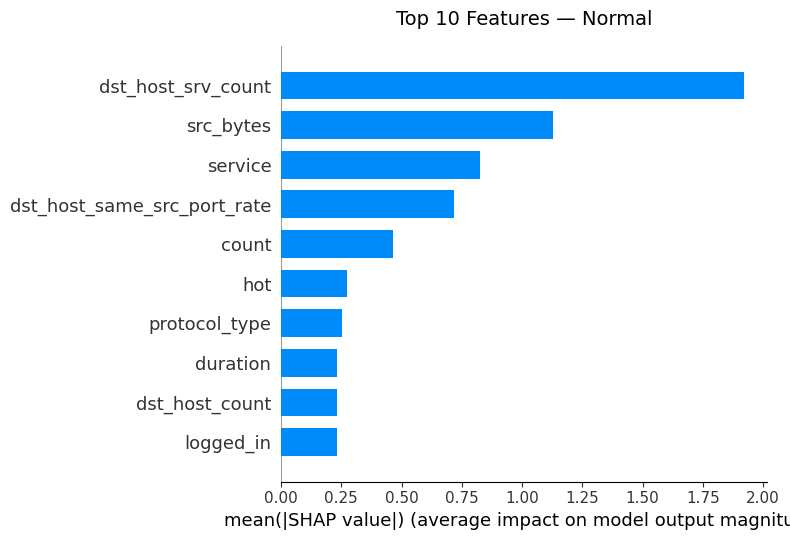

✅ Normal done!



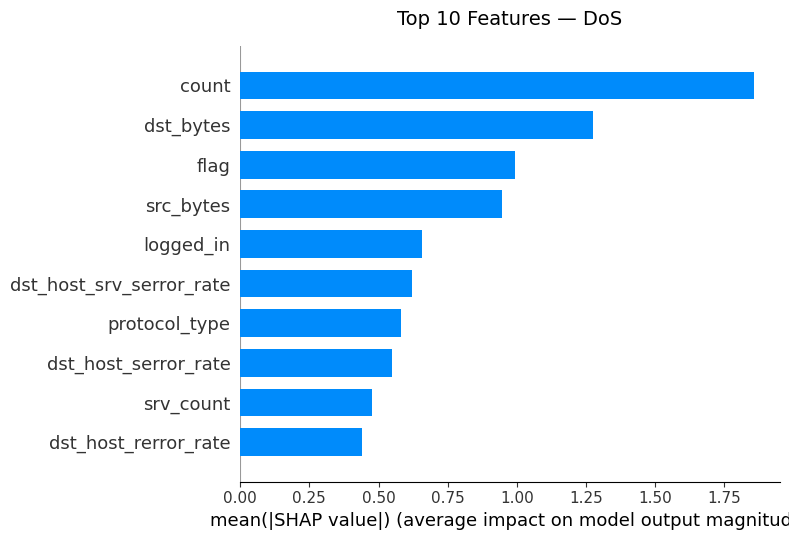

✅ DoS done!



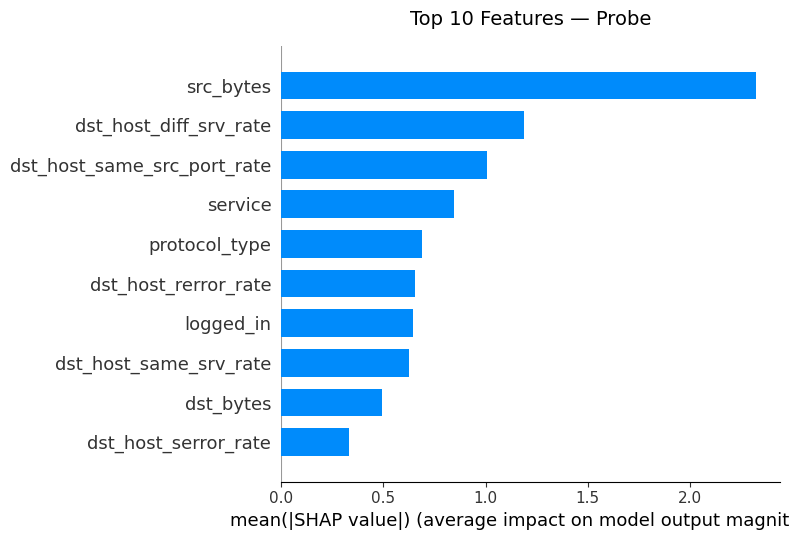

✅ Probe done!



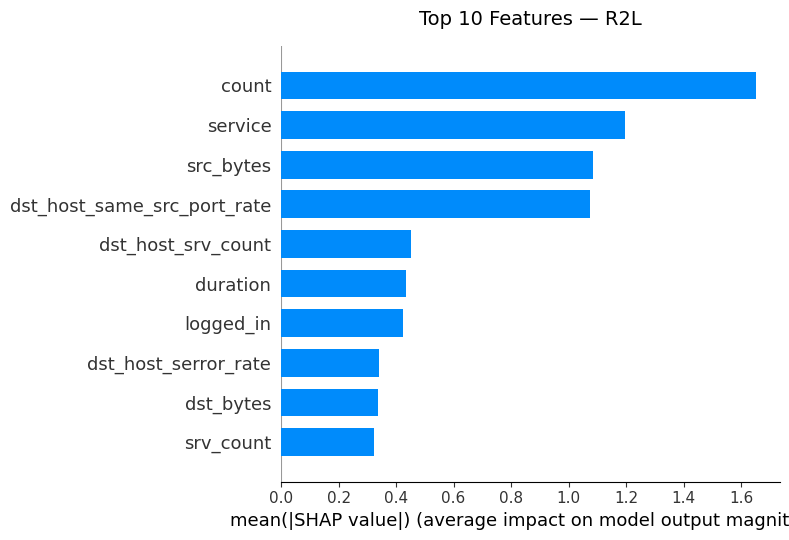

✅ R2L done!



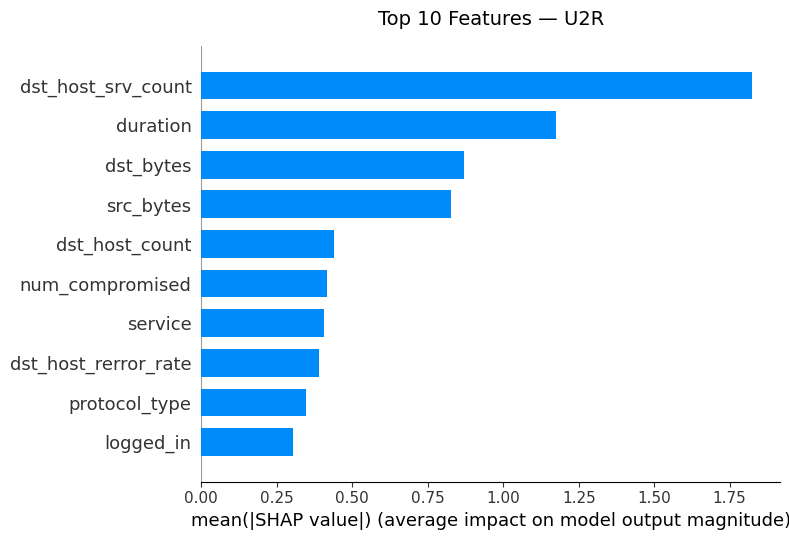

✅ U2R done!



In [9]:
class_names = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']

for i, class_name in enumerate(class_names):
    fig, ax = plt.subplots(figsize=(10, 6))
    plt.sca(ax)
    shap.summary_plot(
        shap_values[:, :, i],
        X_test_df,
        plot_type='bar',
        show=False,
        max_display=10
    )
    ax.set_title(f'Top 10 Features — {class_name}', fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()
    print(f"✅ {class_name} done!\n")

In [10]:
# Pick one suspicious record and explain it
sample_idx = 5
sample = X_test_df.iloc[[sample_idx]]
sample_label = y_test.iloc[sample_idx]

label_names = {0:'Normal', 1:'DoS', 2:'Probe', 3:'R2L', 4:'U2R'}
prediction = xgb_model.predict(sample)[0]

print(f"🔍 Explaining Record #{sample_idx}")
print(f"✅ Actual    : {label_names[sample_label]}")
print(f"✅ Predicted : {label_names[prediction]}")
print(f"\nTop 5 features that caused this decision:")

# Get SHAP values for this record
sample_shap = explainer.shap_values(sample)
class_shap = sample_shap[0, :, prediction]

# Sort by importance
feature_impact = pd.DataFrame({
    'feature': feature_names,
    'impact': np.abs(class_shap)
}).sort_values('impact', ascending=False).head(5)

print(feature_impact.to_string(index=False))

🔍 Explaining Record #5
✅ Actual    : Normal
✅ Predicted : Normal

Top 5 features that caused this decision:
                    feature   impact
         dst_host_srv_count 2.961868
                    service 0.924128
dst_host_srv_diff_host_rate 0.777230
dst_host_same_src_port_rate 0.666527
                  src_bytes 0.635829


In [11]:
# Find a DoS attack record and explain it
dos_indices = y_test[y_test == 1].index[:5]
dos_idx = dos_indices[0]

# Get position in test set
pos = list(y_test.index).index(dos_idx)
sample = X_test_df.iloc[[pos]]
sample_label = y_test.iloc[pos]
prediction = xgb_model.predict(sample)[0]

print(f"🚨 Explaining Attack Record")
print(f"✅ Actual    : {label_names[sample_label]}")
print(f"✅ Predicted : {label_names[prediction]}")
print(f"\nTop 5 features that triggered this alert:")

sample_shap = explainer.shap_values(sample)
class_shap = sample_shap[0, :, prediction]

feature_impact = pd.DataFrame({
    'feature': feature_names,
    'impact': np.abs(class_shap)
}).sort_values('impact', ascending=False).head(5)

print(feature_impact.to_string(index=False))

🚨 Explaining Attack Record
✅ Actual    : DoS
✅ Predicted : DoS

Top 5 features that triggered this alert:
                    feature   impact
                      count 4.339385
                       flag 1.576186
       dst_host_rerror_rate 1.442643
dst_host_same_src_port_rate 0.904855
                  srv_count 0.767347


In [12]:
print("=" * 45)
print("   XAI WITH SHAP COMPLETE!")
print("=" * 45)
print(f"\n✅ SHAP explainer created")
print(f"✅ Feature importance per attack type")
print(f"✅ Explained normal record")
print(f"✅ Explained DoS attack record")
print(f"\n🔍 Key findings:")
print(f"   DoS   → count & flag are biggest factors")
print(f"   Probe → src_bytes matters most")
print(f"   R2L   → src_bytes & dst_host_same_src_port")
print(f"   U2R   → dst_host_srv_count & duration")
print(f"\nDAY 6 → Build FastAPI endpoint! 🚀")

   XAI WITH SHAP COMPLETE!

✅ SHAP explainer created
✅ Feature importance per attack type
✅ Explained normal record
✅ Explained DoS attack record

🔍 Key findings:
   DoS   → count & flag are biggest factors
   Probe → src_bytes matters most
   R2L   → src_bytes & dst_host_same_src_port
   U2R   → dst_host_srv_count & duration

DAY 6 → Build FastAPI endpoint! 🚀
